<a href="https://colab.research.google.com/github/fairouzaboumouslimedoc-maker/Ecole-doctorale-2026/blob/main/ABOU_MOUSLIME_FAIROUZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bibliothèques importées avec succès.
Aperçu des 5 premières lignes du jeu de données:


,Caracteristique_X1,Caracteristique_X2,Caracteristique_X3,Cible_y
0,4.869775,4.625124,6.653063,22.257269
1,7.496622,2.374238,6.123163,20.894761
2,6.589036,2.335332,8.131432,18.254805
3,2.121117,7.595164,6.182372,14.308447
4,0.917118,5.141486,6.181349,11.455854



Le jeu de données contient 100 observations et 3 caractéristiques.

Informations sur le jeu de données:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Caracteristique_X1  100 non-null    float64
 1   Caracteristique_X2  100 non-null    float64
 2   Caracteristique_X3  100 non-null    float64
 3   Cible_y             100 non-null    float64
dtypes: float64(4)
memory usage: 3.3 KB


None

Taille de l'ensemble d'entraînement (X_train): (80, 3)
Taille de l'ensemble de test (X_test): (20, 3)
Modèle de régression linéaire entraîné avec succès.
Coefficients: [ 1.99587485  1.31967817 -0.43743827]
Ordonnée à l'origine: 5.45

Métriques d'évaluation du modèle:
Erreur Absolue Moyenne (MAE): 1.45
Erreur Quadratique Moyenne (MSE): 3.77
Racine Carrée de l'Erreur Quadratique Moyenne (RMSE): 1.94
Coefficient de Détermination (R²): 0.93


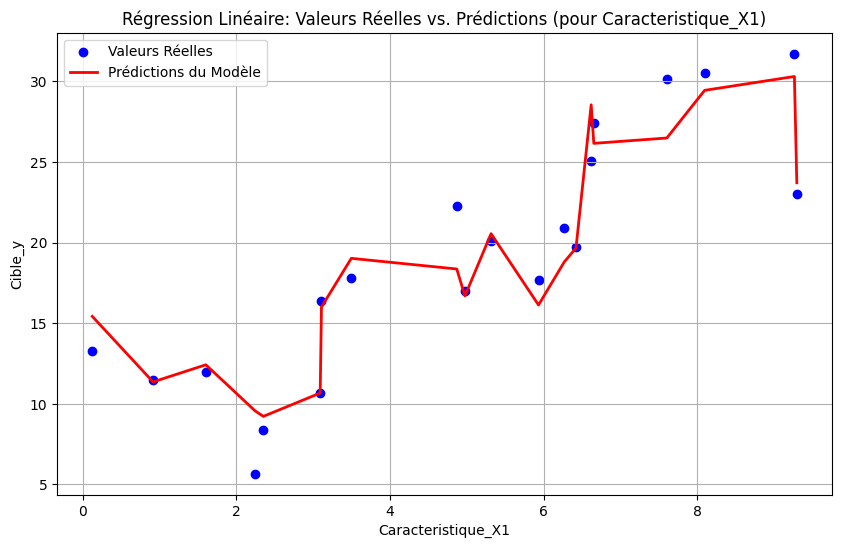

In [4]:
# Exemple Complet de Régression Linéaire en Python

# Ce notebook démontre un exemple complet de régression linéaire en utilisant des bibliothèques Python courantes pour la science des données.

### 1. Importation des bibliothèques nécessaires
# Nous commençons par importer toutes les bibliothèques dont nous aurons besoin pour ce projet.
# - `pandas` est utilisé pour la manipulation et l'analyse des données.
# - `numpy` est essentiel pour les opérations numériques, notamment la création de données synthétiques.
# - `matplotlib.pyplot` et `seaborn` sont utilisés pour la visualisation des données et des résultats.
# - `sklearn.model_selection.train_test_split` pour diviser les données en ensembles d'entraînement et de test.
# - `sklearn.linear_model.LinearRegression` pour le modèle de régression linéaire.
# - `sklearn.metrics` pour évaluer la performance de notre modèle.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Ajout de seaborn pour des visualisations améliorées
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Bibliothèques importées avec succès.")

### 2. Génération et Exploration des Données Synthétiques
# Pour cet exemple, nous allons créer un jeu de données synthétique. Cela nous permet de contrôler la relation entre les variables et de comprendre clairement le comportement du modèle.
# Nous générons trois caractéristiques indépendantes (`X`) et une variable dépendante (`y`) qui a une relation linéaire avec `X`, plus un peu de bruit aléatoire pour simuler des conditions réelles.
# - `n_observations`: Le nombre total d'échantillons dans notre jeu de données.
# - `n_features`: Le nombre de variables indépendantes (caractéristiques) que nous allons générer.
# - Les coefficients définissent la force et la direction de la relation linéaire de chaque caractéristique avec la cible.

# Nombre d'observations et de variables
n_observations = 100
n_features = 3 # Ajout de plusieurs variables indépendantes pour des visualisations plus riches

# Génération des variables indépendantes X
X = np.random.rand(n_observations, n_features) * 10 # Valeurs aléatoires entre 0 et 10 pour 3 caractéristiques

# Génération de la variable dépendante y avec une relation linéaire et du bruit
# Exemple: y = 2*X1 + 1.5*X2 - 0.5*X3 + 5 + bruit_aléatoire
coefficients = np.array([2, 1.5, -0.5])
y = np.dot(X, coefficients) + 5 + np.random.randn(n_observations) * 2

# Création d'un DataFrame Pandas pour une meilleure manipulation
# Nous combinons les caractéristiques (X) et la cible (y) dans un DataFrame pour faciliter l'exploration et la gestion.
column_names = [f'Caracteristique_X{i+1}' for i in range(n_features)]
data = pd.DataFrame(np.hstack((X, y.reshape(-1, 1))), columns=column_names + ['Cible_y'])

# Exploration rapide des données
# `data.head()` affiche les premières lignes du DataFrame pour un aperçu rapide.
# `data.info()` fournit un résumé des colonnes, des types de données et des valeurs non nulles, ce qui est crucial pour identifier les problèmes de qualité des données.
print("Aperçu des 5 premières lignes du jeu de données:")
display(data.head())

print(f"\nLe jeu de données contient {n_observations} observations et {n_features} caractéristiques.")
print("\nInformations sur le jeu de données:")
display(data.info())

### 3. Séparation des Données en Ensembles d'Entraînement et de Test
# Pour évaluer objectivement la performance de notre modèle, nous devons le tester sur des données qu'il n'a pas vues pendant l'entraînement.
# Nous divisons notre jeu de données en deux parties : un ensemble d'entraînement (souvent 80% des données) et un ensemble de test (les 20% restants).
# - `X`: Les caractéristiques (variables indépendantes).
# - `y`: La cible (variable dépendante).
# - `test_size=0.2`: Spécifie que 20% des données seront utilisées pour le test.
# - `random_state=42`: Assure que la division des données est la même à chaque exécution, garantissant la reproductibilité.

# Séparation de X et y
X = data[column_names] # Correction: Sélectionne toutes les colonnes de caractéristiques générées
y = data['Cible_y']

# Séparation des données en 80% entraînement et 20% test
# `random_state` assure la reproductibilité de la séparation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille de l'ensemble d'entraînement (X_train): {X_train.shape}")
print(f"Taille de l'ensemble de test (X_test): {X_test.shape}")

### 4. Entraînement du Modèle de Régression Linéaire
# Ici, nous créons une instance du modèle de régression linéaire (`LinearRegression`) et nous l'"entraînons" sur l'ensemble d'entraînement.
# L'entraînement consiste pour le modèle à apprendre les coefficients (pentes) et l'ordonnée à l'origine qui minimisent la somme des carrés des erreurs entre les prédictions et les valeurs réelles de `y_train`.
# - `model.fit(X_train, y_train)`: Cette méthode ajuste le modèle aux données d'entraînement.
# - `model.coef_`: Les coefficients appris pour chaque caractéristique.
# - `model.intercept_`: L'ordonnée à l'origine (la valeur de y lorsque toutes les caractéristiques sont nulles).

# Création de l'objet régresseur linéaire
model = LinearRegression()

# Entraînement du modèle sur les données d'entraînement
model.fit(X_train, y_train)

print("Modèle de régression linéaire entraîné avec succès.")
# Si le modèle est entraîné avec plusieurs features, model.coef_ sera un tableau
# On peut afficher le premier coefficient pour l'exemple, ou tous les coefficients
print(f"Coefficients: {model.coef_}")
print(f"Ordonnée à l'origine: {model.intercept_:.2f}")

### 5. Prédiction et Évaluation du Modèle
# Une fois le modèle entraîné, nous l'utilisons pour faire des prédictions sur l'ensemble de test (`X_test`).
# Ensuite, nous évaluons la performance de ces prédictions par rapport aux vraies valeurs de `y_test` en utilisant plusieurs métriques courantes.
# - `y_pred = model.predict(X_test)`: Génère les prédictions du modèle sur les données de test.
# - `mean_absolute_error (MAE)`: Mesure l'erreur moyenne entre les prédictions et les valeurs réelles.
# - `mean_squared_error (MSE)`: Pénalise davantage les grandes erreurs.
# - `np.sqrt(mse) (RMSE)`: La racine carrée du MSE, plus interprétable car dans la même unité que la cible.
# - `r2_score (R²)`: Indique la proportion de la variance de la variable cible qui est expliquée par le modèle (de 0 à 1, où 1 est parfait).

# Prédictions sur l'ensemble de test
y_pred = model.predict(X_test)

# Calcul des métriques d'évaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nMétriques d'évaluation du modèle:")
print(f"Erreur Absolue Moyenne (MAE): {mae:.2f}")
print(f"Erreur Quadratique Moyenne (MSE): {mse:.2f}")
print(f"Racine Carrée de l'Erreur Quadratique Moyenne (RMSE): {rmse:.2f}")
print(f"Coefficient de Détermination (R²): {r2:.2f}")

### 6. Visualisation des Résultats
# La visualisation est essentielle pour comprendre intuitivement la performance du modèle. Pour un modèle avec plusieurs caractéristiques, nous ne pouvons pas visualiser toutes les dimensions en même temps.
# Nous choisissons de visualiser les prédictions contre une seule caractéristique (ici, `Caracteristique_X1`) pour avoir une représentation 2D.
# - `plt.scatter()`: Représente les vraies valeurs (`y_test`) par rapport à la caractéristique choisie.
# - `plt.plot()`: Trace la ligne des prédictions (`y_pred`) par rapport à la même caractéristique.
# Le tri des données est crucial pour que la ligne de régression soit correctement affichée.

# Visualisation des Résultats (Modifié pour gérer plusieurs caractéristiques)
# Pour la visualisation, nous allons tracer une des caractéristiques par rapport à la cible.
# Choisissons la première caractéristique pour l'affichage 2D.
plt.figure(figsize=(10, 6))

# Obtenez la première caractéristique pour le traçage
X_test_plot = X_test[column_names[0]]

# Tri X_test_plot et y_pred pour un tracé de ligne correct
# Créez un DataFrame pour trier X_test_plot et y_pred ensemble
plot_data = pd.DataFrame({'X_feature': X_test_plot, 'y_pred': y_pred})
plot_data_sorted = plot_data.sort_values(by='X_feature')

plt.scatter(X_test_plot, y_test, color='blue', label='Valeurs Réelles')
plt.plot(plot_data_sorted['X_feature'], plot_data_sorted['y_pred'], color='red', linewidth=2, label='Prédictions du Modèle')

plt.title(f'Régression Linéaire: Valeurs Réelles vs. Prédictions (pour {column_names[0]})')
plt.xlabel(column_names[0])
plt.ylabel('Cible_y')
plt.legend()
plt.grid(True)
plt.show()